# 🛰️ Satellite Crop Type Classification on Azure
## Student Workbook — Wallonia, Belgium 2023

---

This notebook guides you through the full pipeline from Sentinel-2 data to a crop type classification map.  
**The code cells are intentionally incomplete — you need to fill them in.**

Each cell tells you:
- 🎯 **What** to implement
- 💡 **Hints** where needed
- ✅ **Expected output** so you know if it worked

Use the full tutorial document as a reference if you get stuck.

---

### Study Area
| Parameter | Value |
|---|---|
| Region | Wallonia, Belgium |
| Projection | EPSG:32631 — WGS84 / UTM zone 31N |
| Bounding box (UTM) | Easting 610,000–650,030 m \| Northing 5,571,802–5,602,572 m |
| API bbox (WGS84) | [4.55, 50.25, 5.15, 50.55] |
| Imagery | Sentinel-2 L2A, 2023, cloud < 20% |

### Files provided by your trainer
- `config.py` — pre-filled configuration (add your own `STORAGE_KEY`)
- `wallonia_insitu_2023.shp` + companions — training polygons (LPIS + Walous 2023)
- `crop_dictionary.csv` — class code lookup table
- `test_auth.py`, `test_search.py`, `download_s2.py` — ready-to-run scripts

---

---
# DAY 1 — Data Access & Verification
---

## Step 1 — Load Configuration

Upload `config.py` to JupyterLab (drag and drop into the file browser).  
Open it and fill in your `STORAGE_KEY` (from your Azure storage account → Access keys → key1).

🎯 Import the config and verify all variables are loaded.

In [2]:
# Import all variables from config.py
# YOUR CODE HERE
from config import *
# Verify config loaded correctly — print the storage account name, ROI bbox, and number of bands
# YOUR CODE HERE
print(f"Storage account: {STORAGE_ACCOUNT}")
print(f"ROI: {ROI_BBOX}")
print(f"Bands: {len(BANDS)}")
# ✅ Expected output:
# Storage account: s2wallonia2023
# ROI: [4.55, 50.25, 5.15, 50.55]
# Bands: 11

Storage account: mycropdatakh
ROI: [4.55, 50.25, 5.15, 50.55]
Bands: 11


In [ ]:
import sys
!{sys.executable} -m pip install rasterio azure-storage-blob pystac-client geopandas scikit-learn scipy


## Step 2 — Test Copernicus Authentication

Run `test_auth.py` in the Terminal first:  
```bash
python3 test_auth.py
```

Then implement the authentication function below.  

🎯 Write a function `get_token()` that authenticates with the Copernicus identity server and returns an access token.

💡 The token endpoint is: `https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token`  
💡 You need to POST with `client_id='cdse-public'`, `grant_type='password'`, `username`, `password`  
💡 The token is in `response.json()['access_token']`

In [10]:
import requests

def get_token():
    """
    Authenticate with Copernicus Data Space and return an access token.
    The token expires after 10 minutes.
    """
    url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
    response = requests.post(url, data={
        "client_id":   "cdse-public",
        "grant_type":  "password",
        "username":    COPERNICUS_USER,
        "password":    COPERNICUS_PASS,
    })
    response.raise_for_status()
    return response.json()["access_token"]

# Test it
token = get_token()
print(f'Token obtained: {token[:50]}...')

# ✅ Expected: Token obtained: eyJhbGciOiJSUzI1NiIsInR5cCI6IkpXVC...

Token obtained: eyJhbGciOiJSUzI1NiIsInR5cCIgOiAiSldUIiwia2lkIiA6IC...


## Step 3 — Search the STAC Catalogue

Run `test_search.py` in the Terminal to verify the search works.  
Then implement it yourself below.

🎯 Search the Copernicus STAC catalogue for Sentinel-2 L2A scenes over your ROI.

💡 STAC endpoint: `https://catalogue.dataspace.copernicus.eu/stac`  
💡 Collection name: `sentinel-2-l2a` (not 'SENTINEL-2')  
💡 Use `pystac_client.Client.open()` then `.search()` with `collections`, `bbox`, `datetime`, `query`  
💡 Filter cloud cover with `query={'eo:cloud_cover': {'lt': MAX_CLOUD}}`

In [ ]:
import sys
!{sys.executable} -m pip install pystac-client

In [12]:
from pystac_client import Client
from collections import Counter

# Connect to the STAC catalogue and search for scenes
# YOUR CODE HERE
catalog = Client.open("https://catalogue.dataspace.copernicus.eu/stac")
search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=ROI_BBOX,
    datetime=DATE_RANGE,
    query={"eo:cloud_cover": {"lt": MAX_CLOUD}}
)
# Store results in a variable called 'items'
# YOUR CODE HERE
items = list(search.items())
# Print: total number of scenes found
# Print: number of scenes per month
# Print: list of available asset keys in the first scene
# YOUR CODE HERE
print(f"Found {len(items)} scenes")
months = Counter(item.datetime.strftime("%Y-%m") for item in items)
for month, count in sorted(months.items()):
    print(f"  {month}: {count} scenes")
print("\nAvailable assets:")
for key in items[0].assets:
    print(f"  {key}: ✅")
# ✅ Expected:
# Found 39 scenes
# 2023-02: 3 scenes  ...  2023-10: 2 scenes
# B02_10m: ✅  B03_10m: ✅  ...  SCL_20m: ✅

Found 39 scenes
  2023-02: 3 scenes
  2023-03: 2 scenes
  2023-04: 2 scenes
  2023-05: 2 scenes
  2023-06: 16 scenes
  2023-07: 1 scenes
  2023-08: 5 scenes
  2023-09: 6 scenes
  2023-10: 2 scenes

Available assets:
  AOT_10m: ✅
  AOT_20m: ✅
  AOT_60m: ✅
  B01_20m: ✅
  B01_60m: ✅
  B02_10m: ✅
  B02_20m: ✅
  B02_60m: ✅
  B03_10m: ✅
  B03_20m: ✅
  B03_60m: ✅
  B04_10m: ✅
  B04_20m: ✅
  B04_60m: ✅
  B05_20m: ✅
  B05_60m: ✅
  B06_20m: ✅
  B06_60m: ✅
  B07_20m: ✅
  B07_60m: ✅
  B08_10m: ✅
  B09_60m: ✅
  B11_20m: ✅
  B11_60m: ✅
  B12_20m: ✅
  B12_60m: ✅
  B8A_20m: ✅
  B8A_60m: ✅
  CLD_20m: ✅
  CLD_60m: ✅
  Product: ✅
  SCL_20m: ✅
  SCL_60m: ✅
  SNW_20m: ✅
  SNW_60m: ✅
  TCI_10m: ✅
  TCI_20m: ✅
  TCI_60m: ✅
  WVP_10m: ✅
  WVP_20m: ✅
  WVP_60m: ✅
  thumbnail: ✅
  safe_manifest: ✅
  granule_metadata: ✅
  inspire_metadata: ✅
  product_metadata: ✅
  datastrip_metadata: ✅


## Step 4 — Download Sentinel-2 Data

Run `download_s2.py` in a Terminal — do not run it in a notebook cell as it takes 2–4 hours:  
```bash
python3 download_s2.py
```

While it runs, implement the Azure Blob Storage helper functions below — you will need them from Day 2 onwards.

🎯 Write three functions: `get_cc()`, `read_blob()`, `write_blob()`

💡 `BlobServiceClient.from_connection_string(conn_str)` creates the client  
💡 Use `MemoryFile` from rasterio to read/write rasters in memory without saving to disk  
💡 Connection string format: `DefaultEndpointsProtocol=https;AccountName=...;AccountKey=...;EndpointSuffix=core.windows.net`

In [4]:
import numpy as np
import rasterio
from rasterio.io import MemoryFile
from azure.storage.blob import BlobServiceClient

NO_DATA = -9999.0

def get_cc():
    """
    Return an Azure Blob container client using credentials from config.
    """
    # Build connection string and return container client
    # YOUR CODE HERE
    conn_str = (
        f"DefaultEndpointsProtocol=https;"
        f"AccountName={STORAGE_ACCOUNT};"
        f"AccountKey={STORAGE_KEY};"
        f"EndpointSuffix=core.windows.net"
    )
    client = BlobServiceClient.from_connection_string(conn_str)
    return client.get_container_client(CONTAINER_NAME)


def read_blob(blob_name):
    """
    Download a raster file from Blob Storage and return it as a numpy array.
    Returns: (array, rasterio_profile)
    """
    # 1. Download the blob bytes using get_cc()
    # 2. Open with MemoryFile and rasterio
    # 3. Read band 1 as float32
    # 4. Return (array, profile)
    # YOUR CODE HERE
    data = get_cc().download_blob(blob_name).readall()
    with MemoryFile(data) as memfile:
        with memfile.open() as ds:
            arr = ds.read(1).astype("float32")
            profile = ds.profile
    return arr, profile


def write_blob(arr, profile, blob_name):
    prof = profile.copy()
    prof.update(dtype="float32", count=1, nodata=NO_DATA, driver="GTiff")
    with MemoryFile() as memfile:
        with memfile.open(**prof) as ds:
            ds.write(arr.astype("float32"), 1)
        get_cc().upload_blob(blob_name, memfile.read(), overwrite=True)
    print(f"Saved: {blob_name}")



# Test: list files in Blob Storage
cc    = get_cc()
blobs = [b.name for b in cc.list_blobs(name_starts_with='raw/')]
print(f'Files in Blob Storage: {len(blobs)}')

# Count files per band
import re
from collections import Counter
band_counts = Counter()
for b in blobs:
    m = re.search(r'_(B\w+|SCL_\w+)\.tif$', b)
    if m: band_counts[m.group(1)] += 1
print('Files per band:')
for band, n in sorted(band_counts.items()):
    print(f'  {band:10s}: {n} scenes')

# ✅ Expected: ~39 files per band (may be less if download still running)

Files in Blob Storage: 242
Files per band:
  B02_10m   : 22 scenes
  B03_10m   : 22 scenes
  B04_10m   : 22 scenes
  B05_20m   : 22 scenes
  B06_20m   : 22 scenes
  B07_20m   : 22 scenes
  B08_10m   : 22 scenes
  B11_20m   : 22 scenes
  B12_20m   : 22 scenes
  B8A_20m   : 22 scenes
  SCL_20m   : 22 scenes


---
# DAY 2 — Cloud Masking, Compositing & Feature Stack
---

## Step 5 — Group Scenes by Month

🎯 Build a nested dictionary `monthly` that groups blob paths by month and band.  
Structure: `monthly['202306']['B04_10m'] = ['raw/T31UFS/20230601_B04_10m.tif', ...]`

💡 Use a regex on the blob name to extract the 6-digit month (YYYYMM) and band name  
💡 `defaultdict(lambda: defaultdict(list))` is useful here

In [4]:
from collections import defaultdict
import re

# First get the list of all blobs
blobs = [b.name for b in get_cc().list_blobs(name_starts_with='raw/')]

# Build the monthly grouping dictionary
monthly = defaultdict(lambda: defaultdict(list))

for blob in blobs:
    # Extract YYYYMM and band name from filename like: raw/T31UFS/20230615_B04_10m.tif
    m = re.search(r'/(\d{6})\d{2}_(B\w+|SCL_\w+)\.tif$', blob)
    if m:
        month = m.group(1)   # e.g. '202306'
        band  = m.group(2)   # e.g. 'B04_10m'
        monthly[month][band].append(blob)

# Print months available and B04 scene counts
print("Months:", sorted(monthly.keys()))
for month in sorted(monthly.keys()):
    n = len(monthly[month].get('B04_10m', []))
    print(f"  {month}: {n} B04 scenes")


# Build the monthly grouping dictionary
# YOUR CODE HERE

# Print: months available and number of B04_10m scenes per month
# YOUR CODE HERE

# ✅ Expected:
# Months: ['202302', '202303', ..., '202310']
# 202302: 3 B04 scenes   202306: 16 B04 scenes   etc.

Months: ['202302', '202303', '202304', '202305', '202306', '202307', '202308', '202309', '202310']
  202302: 2 B04 scenes
  202303: 1 B04 scenes
  202304: 1 B04 scenes
  202305: 2 B04 scenes
  202306: 8 B04 scenes
  202307: 1 B04 scenes
  202308: 3 B04 scenes
  202309: 3 B04 scenes
  202310: 1 B04 scenes


## Step 6 — Cloud Masking Function

The SCL (Scene Classification Layer) labels each pixel. We keep only valid pixels.

| SCL value | Meaning | Keep? |
|---|---|---|
| 4 | Vegetation | ✅ |
| 5 | Non-vegetated | ✅ |
| 6 | Water | ✅ |
| 7 | Unclassified | ✅ |
| 11 | Snow/Ice | ✅ |
| All others | Cloud, shadow, saturated | ❌ |

🎯 Apply the SCL mask inside the compositing loop: set masked pixels to `np.nan`.

💡 `np.isin(scl_arr.astype(int), VALID_SCL)` creates a boolean mask  
💡 `np.where(mask, arr, np.nan)` applies it

## Step 7 — Monthly Median Composites

🎯 For each month and each feature band:  
1. Load the SCL array for that month  
2. Load all scenes for that band  
3. Apply cloud mask to each scene  
4. Stack scenes and compute pixel-wise median (NaN-aware)  
5. Replace remaining NaN with NO_DATA  
6. Save composite to `composites/{month}_{band}.tif` in Blob Storage

💡 `np.nanmedian(np.stack(scene_list, axis=0), axis=0)` computes the NaN-aware median  
💡 Feature bands = all BANDS except `SCL_20m`  
💡 Store the first valid `profile` as `ref_profile` — you'll need it later

In [27]:
VALID_SCL  = [4, 5, 6, 7, 11]
FEAT_BANDS = [b for b in BANDS if b != 'SCL_20m']
ref_profile = None

for month in sorted(monthly.keys()):
    print(f'\nProcessing {month}...')

    # 1. Load SCL for this month
    scl_blobs = monthly[month].get('SCL_20m', [])
    if not scl_blobs:
        print(f'  No SCL for {month}, skipping')
        continue
    scl_arr, _ = read_blob(scl_blobs[0])

    for band in FEAT_BANDS:
        band_blobs = monthly[month].get(band, [])
        if not band_blobs:
            print(f'  {band}: no data, skipping')
            continue

        stack = []
        for blob in band_blobs:
            # 2. Load band array
            arr, profile = read_blob(blob)

            # Store first valid profile
            if ref_profile is None:
                ref_profile = profile

            # Upsample SCL to match band resolution if needed
            if scl_arr.shape != arr.shape:
                factor = arr.shape[0] // scl_arr.shape[0]
                scl_up = np.repeat(np.repeat(scl_arr, factor, axis=0), factor, axis=1)
            else:
                scl_up = scl_arr

            # 3. Apply cloud mask
            mask   = np.isin(scl_up.astype(int), VALID_SCL)
            masked = np.where(mask, arr, np.nan)

            # 4. Append to stack
            stack.append(masked)

        # 5. Compute NaN-aware median across all scenes
        composite = np.nanmedian(np.stack(stack, axis=0), axis=0)

        # 6. Replace remaining NaN with NO_DATA and save
        composite = np.where(np.isnan(composite), NO_DATA, composite)
        out_name  = f'composites/{month}_{band}.tif'
        write_blob(composite, profile, out_name)

print('\nAll composites done!')




Processing 202302...
Saved: composites/202302_B02_10m.tif
Saved: composites/202302_B03_10m.tif
Saved: composites/202302_B04_10m.tif
Saved: composites/202302_B05_20m.tif
Saved: composites/202302_B06_20m.tif
Saved: composites/202302_B07_20m.tif
Saved: composites/202302_B08_10m.tif
Saved: composites/202302_B8A_20m.tif
Saved: composites/202302_B11_20m.tif
Saved: composites/202302_B12_20m.tif

Processing 202303...
Saved: composites/202303_B02_10m.tif
Saved: composites/202303_B03_10m.tif
Saved: composites/202303_B04_10m.tif
Saved: composites/202303_B05_20m.tif
Saved: composites/202303_B06_20m.tif
Saved: composites/202303_B07_20m.tif
Saved: composites/202303_B08_10m.tif
Saved: composites/202303_B8A_20m.tif
Saved: composites/202303_B11_20m.tif
Saved: composites/202303_B12_20m.tif

Processing 202304...
Saved: composites/202304_B02_10m.tif
Saved: composites/202304_B03_10m.tif
Saved: composites/202304_B04_10m.tif
Saved: composites/202304_B05_20m.tif
Saved: composites/202304_B06_20m.tif
Saved: co

## Step 8 — Spectral Indices

Compute three indices for each month to enrich your feature set.

| Index | Formula | What it captures |
|---|---|---|
| NDVI | (B08 - B04) / (B08 + B04) | Vegetation density and health |
| NDWI | (B03 - B08) / (B03 + B08) | Water bodies, irrigation |
| NDBI | (B11 - B08) / (B11 + B08) | Built-up surfaces |

🎯 For each month: load the relevant composites, compute the three indices, save each to Blob Storage.

💡 Avoid division by zero: use `np.where(denominator != 0, (a-b)/(a+b), NO_DATA)`  
💡 Clip values to [-1, 1] — NDVI outside this range indicates a bad pixel

In [6]:
def safe_index(a, b):
    """
    Compute a normalised difference index: (a - b) / (a + b)
    Returns NO_DATA where denominator is zero.
    Clips result to [-1, 1].
    """
    denom = a + b
    result = np.where(denom != 0, (a - b) / denom, NO_DATA)
    return np.clip(result, -1, 1)


for month in sorted(monthly.keys()):
    print(f'Indices for {month}...')

    # Load B03, B04, B08, B11 composites for this month
    # Replace NO_DATA with np.nan before computing indices
    b03, profile = read_blob(f'composites/{month}_B03_10m.tif')
    b04, _       = read_blob(f'composites/{month}_B04_10m.tif')
    b08, _       = read_blob(f'composites/{month}_B08_10m.tif')
    b11, _       = read_blob(f'composites/{month}_B11_20m.tif')

    for arr in [b03, b04, b08, b11]:
        arr[arr == NO_DATA] = np.nan

    if b11.shape != b08.shape:
        factor = b08.shape[0] // b11.shape[0]
        b11 = np.repeat(np.repeat(b11, factor, axis=0), factor, axis=1)

    # Compute and save NDVI, NDWI, NDBI
    ndvi = safe_index(b08, b04)
    ndwi = safe_index(b03, b08)
    ndbi = safe_index(b11, b08)

    write_blob(ndvi, profile, f'composites/{month}_NDVI.tif')
    write_blob(ndwi, profile, f'composites/{month}_NDWI.tif')
    write_blob(ndbi, profile, f'composites/{month}_NDBI.tif')

print('Spectral indices done!')

# ✅ Expected: 3 index files per month saved to composites/
# e.g. composites/202306_NDVI.tif  composites/202306_NDWI.tif  composites/202306_NDBI.tif

Indices for 202302...
Saved: composites/202302_NDVI.tif
Saved: composites/202302_NDWI.tif
Saved: composites/202302_NDBI.tif
Indices for 202303...
Saved: composites/202303_NDVI.tif
Saved: composites/202303_NDWI.tif
Saved: composites/202303_NDBI.tif
Indices for 202304...
Saved: composites/202304_NDVI.tif
Saved: composites/202304_NDWI.tif
Saved: composites/202304_NDBI.tif
Indices for 202305...
Saved: composites/202305_NDVI.tif
Saved: composites/202305_NDWI.tif
Saved: composites/202305_NDBI.tif
Indices for 202306...
Saved: composites/202306_NDVI.tif
Saved: composites/202306_NDWI.tif
Saved: composites/202306_NDBI.tif
Indices for 202307...
Saved: composites/202307_NDVI.tif
Saved: composites/202307_NDWI.tif
Saved: composites/202307_NDBI.tif
Indices for 202308...
Saved: composites/202308_NDVI.tif
Saved: composites/202308_NDWI.tif
Saved: composites/202308_NDBI.tif
Indices for 202309...


/tmp/ipykernel_6070/2974399620.py:8: RuntimeWarning: invalid value encountered in divide
  result = np.where(denom != 0, (a - b) / denom, NO_DATA)


Saved: composites/202309_NDVI.tif
Saved: composites/202309_NDWI.tif
Saved: composites/202309_NDBI.tif
Indices for 202310...
Saved: composites/202310_NDVI.tif
Saved: composites/202310_NDWI.tif
Saved: composites/202310_NDBI.tif
Spectral indices done!


## Step 9 — Assemble the Feature Stack

🎯 Load all composite files from Blob Storage and stack them into a single 3D NumPy array.

The result should have shape `(rows, cols, n_features)` where `n_features` is the total number of band-month combinations.

💡 `np.dstack(list_of_2d_arrays)` stacks along the third axis  
💡 Save `feat_names` (the ordered list of feature names) to a JSON file — you'll need it on Day 3

In [7]:
import json
import numpy as np
from rasterio.io import MemoryFile
from rasterio.windows import from_bounds
from pyproj import Transformer

transformer = Transformer.from_crs(4326, 32631, always_xy=True)
left,  bottom = transformer.transform(ROI_BBOX[0], ROI_BBOX[1])
right, top    = transformer.transform(ROI_BBOX[2], ROI_BBOX[3])
roi_bounds = (left, bottom, right, top)

def read_blob_roi(blob_name):
    data = get_cc().download_blob(blob_name).readall()
    with MemoryFile(data) as memfile:
        with memfile.open() as ds:
            window  = from_bounds(*roi_bounds, ds.transform)
            arr     = ds.read(1, window=window).astype("float32")
            profile = ds.profile.copy()
            profile.update(width=arr.shape[1], height=arr.shape[0],
                           transform=ds.window_transform(window))
    return arr, profile

comp_blobs = sorted([b.name for b in get_cc().list_blobs(name_starts_with='composites/')])

arr0, ref_profile = read_blob_roi(comp_blobs[0])
rows, cols = arr0.shape
n_feat = len(comp_blobs)

feat_arr   = np.empty((rows, cols, n_feat), dtype=np.float32)
feat_names = []

feat_arr[:, :, 0] = arr0
feat_names.append(comp_blobs[0].replace('composites/', '').replace('.tif', ''))

for i, blob in enumerate(comp_blobs[1:], start=1):
    arr, _ = read_blob_roi(blob)
    if arr.shape != (rows, cols):
        factor = rows // arr.shape[0]
        arr = np.repeat(np.repeat(arr, factor, axis=0), factor, axis=1)
        out = np.full((rows, cols), NO_DATA, dtype=np.float32)
        r = min(arr.shape[0], rows)
        c = min(arr.shape[1], cols)
        out[:r, :c] = arr[:r, :c]
        arr = out
    feat_arr[:, :, i] = arr
    feat_names.append(blob.replace('composites/', '').replace('.tif', ''))
    if i % 10 == 0:
        print(f'  Loaded {i}/{n_feat}...')

print(f'Feature stack shape: {feat_arr.shape}')
print(f'Number of features: {len(feat_names)}')
print(f'First 5 features: {feat_names[:5]}')

with open('feature_names.json', 'w') as f:
    json.dump(feat_names, f)
print('Saved feature_names.json')



# ✅ Expected:
# Feature stack shape: (3100, 4000, 156)  <- rows × cols × features
# First features: ['202302_B02_10m', '202302_B03_10m', ...]

  Loaded 10/117...
  Loaded 20/117...
  Loaded 30/117...
  Loaded 40/117...
  Loaded 50/117...
  Loaded 60/117...
  Loaded 70/117...
  Loaded 80/117...
  Loaded 90/117...
  Loaded 100/117...
  Loaded 110/117...
Feature stack shape: (3246, 4181, 117)
Number of features: 117
First 5 features: ['202302_B02_10m', '202302_B03_10m', '202302_B04_10m', '202302_B05_20m', '202302_B06_20m']
Saved feature_names.json


---
# DAY 3 — Feature Selection & Classification
---

## Step 10 — Reload Feature Stack

Start a fresh notebook or restart the kernel. Reload everything from Blob Storage.

🎯 Reload `feat_arr` and `feat_names` from Blob Storage and `feature_names.json`.

In [5]:
# Paste your helper functions (get_cc, read_blob, write_blob) here
# YOUR CODE HERE

# Load feature names from feature_names.json
# YOUR CODE HERE

# Reload all composites and rebuild feat_arr
# (same code as Step 9 — you can copy it)
# YOUR CODE HERE

# Reload config and imports
from config import *
import numpy as np
import json
import rasterio
from rasterio.io import MemoryFile
from rasterio.windows import from_bounds
from azure.storage.blob import BlobServiceClient
from pyproj import Transformer

NO_DATA = -9999.0

# Paste your helper functions
def get_cc():
    conn_str = (
        f"DefaultEndpointsProtocol=https;"
        f"AccountName={STORAGE_ACCOUNT};"
        f"AccountKey={STORAGE_KEY};"
        f"EndpointSuffix=core.windows.net"
    )
    client = BlobServiceClient.from_connection_string(conn_str)
    return client.get_container_client(CONTAINER_NAME)

def read_blob(blob_name):
    data = get_cc().download_blob(blob_name).readall()
    with MemoryFile(data) as memfile:
        with memfile.open() as ds:
            arr = ds.read(1).astype("float32")
            profile = ds.profile
    return arr, profile

def write_blob(arr, profile, blob_name):
    prof = profile.copy()
    prof.update(dtype="float32", count=1, nodata=NO_DATA, driver="GTiff")
    with MemoryFile() as memfile:
        with memfile.open(**prof) as ds:
            ds.write(arr.astype("float32"), 1)
        get_cc().upload_blob(blob_name, memfile.read(), overwrite=True)
    print(f"Saved: {blob_name}")

transformer = Transformer.from_crs(4326, 32631, always_xy=True)
left, bottom = transformer.transform(ROI_BBOX[0], ROI_BBOX[1])
right, top = transformer.transform(ROI_BBOX[2], ROI_BBOX[3])
roi_bounds = (left, bottom, right, top)

def read_blob_roi(blob_name):
    data = get_cc().download_blob(blob_name).readall()
    with MemoryFile(data) as memfile:
        with memfile.open() as ds:
            window = from_bounds(*roi_bounds, ds.transform)
            arr = ds.read(1, window=window).astype("float32")
            profile = ds.profile.copy()
            profile.update(width=arr.shape[1], height=arr.shape[0],
                           transform=ds.window_transform(window))
    return arr, profile

# Load feature names
with open('feature_names.json', 'r') as f:
    feat_names = json.load(f)

# Rebuild feature stack from composites
comp_blobs = sorted([b.name for b in get_cc().list_blobs(name_starts_with='composites/')
                     if '/' not in b.name.replace('composites/', '')])

arr0, ref_profile = read_blob_roi(comp_blobs[0])
rows, cols = arr0.shape
n_feat = len(comp_blobs)

feat_arr = np.empty((rows, cols, n_feat), dtype=np.float32)
feat_arr[:, :, 0] = arr0

for i, blob in enumerate(comp_blobs[1:], start=1):
    arr, _ = read_blob_roi(blob)
    if arr.shape != (rows, cols):
        factor = rows // arr.shape[0]
        arr = np.repeat(np.repeat(arr, factor, axis=0), factor, axis=1)
        out = np.full((rows, cols), NO_DATA, dtype=np.float32)
        r = min(arr.shape[0], rows)
        c = min(arr.shape[1], cols)
        out[:r, :c] = arr[:r, :c]
        arr = out
    feat_arr[:, :, i] = arr
    if i % 10 == 0:
        print(f'  Loaded {i}/{n_feat}...')

print(f'Feature stack: {feat_arr.shape}')

  Loaded 10/117...
  Loaded 20/117...
  Loaded 30/117...
  Loaded 40/117...
  Loaded 50/117...
  Loaded 60/117...
  Loaded 70/117...
  Loaded 80/117...
  Loaded 90/117...
  Loaded 100/117...
  Loaded 110/117...
Feature stack: (3246, 4181, 117)


## Step 11 — Rasterize Training Data

Upload the training shapefile to JupyterLab (drag and drop all 4 files: `.shp`, `.dbf`, `.shx`, `.prj`).

🎯 Load the shapefile, check/fix the CRS, and rasterize the training polygons onto the same grid as your feature stack.

💡 Use `gpd.read_file()` to load, `.to_crs()` to reproject if needed  
💡 Use `rasterio.features.rasterize()` with `out_shape`, `fill`, `transform` from `ref_profile`  
💡 The field with crop/landcover codes is `grp_1_nb`

In [7]:
import geopandas as gpd
from rasterio.features import rasterize as rio_rasterize

IN_SITU_SHP = 'lpis2023_walous2023_train_area_prop.shp'
FIELD_CODE = 'class_id' # change it to class_id for the crop codes

# 1. Load the shapefile
gdf = gpd.read_file(IN_SITU_SHP)

# 2. Print: number of polygons, CRS, unique crop codes
print(f"Polygons: {len(gdf)}")
print(f"CRS: {gdf.crs}")
print(f"Columns: {list(gdf.columns)}")
print(f"Unique crop codes: {gdf[FIELD_CODE].nunique()}")
print(f"\nSample classes:")
print(gdf[FIELD_CODE].value_counts().head(10))

# 3. Check CRS matches raster — reproject if not
raster_crs = ref_profile['crs']
if gdf.crs != raster_crs:
    gdf = gdf.to_crs(raster_crs)
    print(f"\nReprojected to {raster_crs}")

# 4. Rasterize: burn FIELD_CODE values onto a grid matching feat_arr
# Use fill=int(NO_DATA) for pixels outside polygons
shapes = [(geom, val) for geom, val in zip(gdf.geometry, gdf[FIELD_CODE])]

cal_arr = rio_rasterize(
    shapes,
    out_shape=(ref_profile['height'], ref_profile['width']),
    fill=int(NO_DATA),
    transform=ref_profile['transform'],
    dtype='int32'
)

# 5. Print: number of training pixels and number of classes
train_mask = cal_arr != int(NO_DATA)
print(f"\nTraining pixels: {train_mask.sum():,}")
print(f"Classes: {len(np.unique(cal_arr[train_mask]))}")
print(f"cal_arr shape: {cal_arr.shape}")

# ✅ Expected:
# Training pixels: ~35,000+
# Classes: 15–25 unique crop/landcover types

Polygons: 1467
CRS: EPSG:32631
Columns: ['src', 'orig_code', 'orig_label', 'class_id', 'class_name', 'class_grou', 'area_m2', 'poly_area', 'target_are', 'sampled_ar', 'geometry']
Unique crop codes: 110

Sample classes:
class_id
1007    273
1009    239
34      202
1001    149
1002    126
3        96
1        41
1006     35
54       30
5        27
Name: count, dtype: int64

Training pixels: 594,405
Classes: 110
cal_arr shape: (3246, 4181)


In [8]:
print(gdf[['class_id', 'class_name', 'class_grou']].drop_duplicates().sort_values('class_id').to_string())

      class_id                                                                                             class_name class_grou
0            1                                                                                          Maïs ensilage       crop
41           2                                                                                             Maïs grain       crop
45           3                                                                                        Froment d'hiver       crop
141          4                                                                                   Froment de printemps       crop
142          5                                                                                           Orge d'hiver       crop
169          6                                                                                      Orge de printemps       crop
170          7                                                                                   

## Step 12 — Build X and y, Train/Test Split

🎯 Extract the feature matrix X and label vector y from pixels that have training labels.

💡 Boolean mask: `mask = cal_arr != int(NO_DATA)`  
💡 `X = feat_arr[mask, :]` — shape (n_samples, n_features)  
💡 Use `train_test_split` with `stratify=y` to ensure all classes appear in both sets

In [9]:
from sklearn.model_selection import train_test_split

# 1. Create boolean mask of labeled pixels
mask = cal_arr != int(NO_DATA)

# 2. Extract X (features) and y (labels)
X = feat_arr[mask, :]
y = cal_arr[mask]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# 3. Replace NaN in X with NO_DATA
X = np.where(np.isnan(X), NO_DATA, X)

# 4. Stratified 80/20 train/test split
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Print shapes
print(f"\nTraining: {X_tr.shape[0]:,} samples")
print(f"Test:     {X_te.shape[0]:,} samples")
print(f"Features: {X_tr.shape[1]}")
print(f"Classes:  {len(np.unique(y_tr))}")

# ✅ Expected:
# X shape: (n_samples, n_features)
# Training: ~28,000  |  Test: ~7,000

X shape: (594405, 117)
y shape: (594405,)

Training: 475,524 samples
Test:     118,881 samples
Features: 117
Classes:  110


## Step 13 — Feature Selection

With up to 156 features, not all are equally useful. Use a quick Random Forest to rank them.

🎯 Train a fast Random Forest on a 10,000-pixel subsample and rank features by Gini importance.

**Group discussion:** After plotting the importances, answer these questions before selecting your subset:
- Which months are most important? Does this make agronomic sense for Wallonia?
- Which bands appear most often in the top features?
- Are the spectral indices (NDVI, NDWI, NDBI) useful?
- How many features do you need before importance drops off significantly?

💡 Use `n_estimators=50` for speed  
💡 `rf.feature_importances_` gives the Gini importance of each feature



Top 15 features:
       feature  importance
202305_B05_20m    0.013213
202305_B11_20m    0.012965
202310_B12_20m    0.012601
202305_B12_20m    0.012389
202306_B05_20m    0.012315
202303_B12_20m    0.012082
202308_B11_20m    0.012075
202310_B11_20m    0.012026
202306_B11_20m    0.012018
202302_B02_10m    0.011805
202309_B06_20m    0.011627
202310_B05_20m    0.011626
202303_B8A_20m    0.011613
202303_B05_20m    0.011574
202309_B05_20m    0.011492


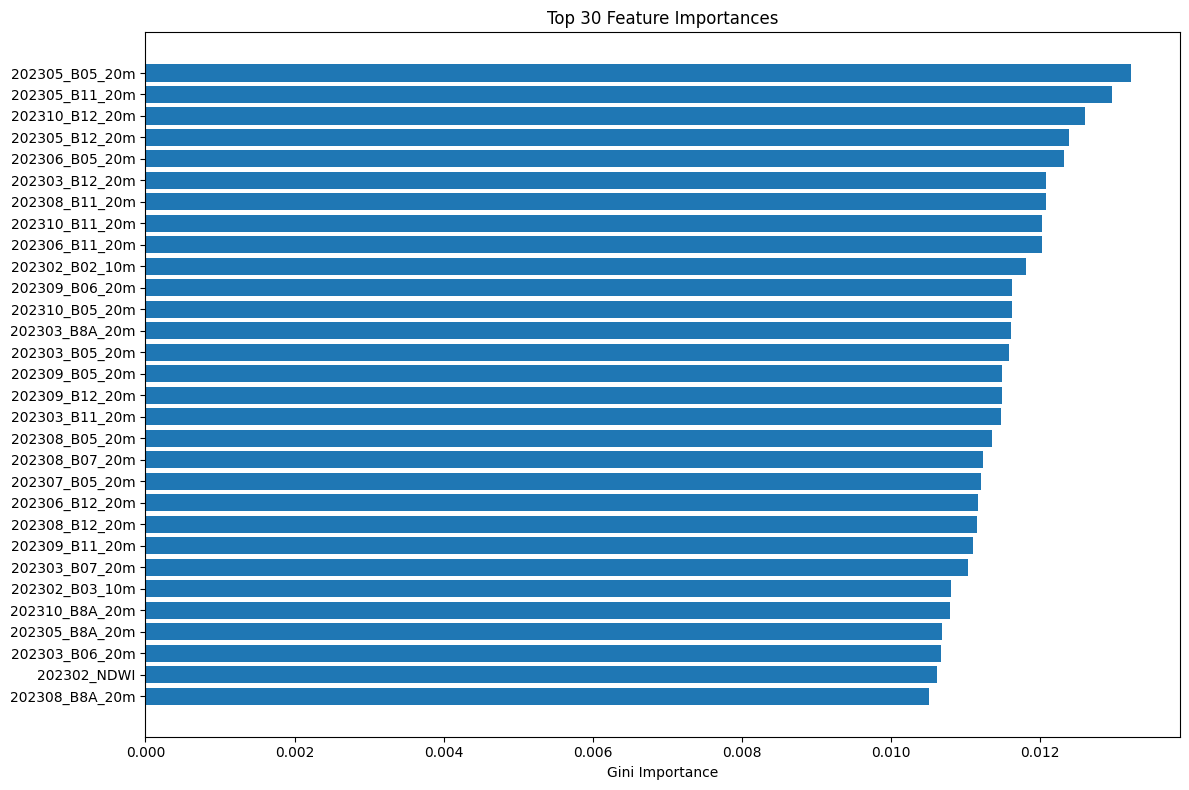

Saved feature_importance.png


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# 1. Subsample 10,000 training pixels randomly
np.random.seed(42)
idx = np.random.choice(len(X_tr), size=10000, replace=False)
X_sub = X_tr[idx]
y_sub = y_tr[idx]

# 2. Train a quick Random Forest (50 trees) on the subsample
rf_quick = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)
rf_quick.fit(X_sub, y_sub)
print(f"Quick RF accuracy on subsample: {rf_quick.oob_score_:.3f}" if hasattr(rf_quick, 'oob_score_') else "")

# 3. Build a DataFrame of feature importances, sorted descending
importance_df = pd.DataFrame({
    'feature': feat_names,
    'importance': rf_quick.feature_importances_
}).sort_values('importance', ascending=False)

# 4. Print top 15 features
print("\nTop 15 features:")
print(importance_df.head(15).to_string(index=False))

# 5. Plot top 30 as a bar chart, save as feature_importance.png
fig, ax = plt.subplots(figsize=(12, 8))
top30 = importance_df.head(30)
ax.barh(range(len(top30)), top30['importance'].values)
ax.set_yticks(range(len(top30)))
ax.set_yticklabels(top30['feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Gini Importance')
ax.set_title('Top 30 Feature Importances')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=200)
plt.show()
print("Saved feature_importance.png")

# ✅ Expected: bar chart showing top 30 features by importance

In [16]:
# FEATURE SELECTION — discuss with your group before running this cell

# How many features will you keep? Justify your choice:
# (Consider: accuracy vs training speed, which features matter most)
TOP_N = 60  # <-- set this after your group discussion

# Select top N features
selected = importance_df.head(TOP_N)['feature'].to_list()
selected_idx = [feat_names.index(f) for f in selected]

X_tr_sel = X_tr[:, selected_idx]
X_te_sel = X_te[:, selected_idx]
# Create subsetted versions of your training/test matrices and the image
# X_tr_sel, X_te_sel, img_flat_sel
# YOUR CODE HERE

print(f'Selected {TOP_N} features for training.')
print(f'Top features: {selected[:10]}')

Selected 60 features for training.
Top features: ['202305_B05_20m', '202305_B11_20m', '202310_B12_20m', '202305_B12_20m', '202306_B05_20m', '202303_B12_20m', '202308_B11_20m', '202310_B11_20m', '202306_B11_20m', '202302_B02_10m']


## Step 14 — Train the Random Forest

🎯 Train a full Random Forest classifier on the selected features.

💡 Use `n_estimators=100`, `oob_score=True`, `n_jobs=-1` (uses all CPU cores)  
💡 OOB (Out-of-Bag) score is a free accuracy estimate on data not seen by each tree — a useful sanity check  
💡 Aim for OOB > 80%. If lower, revisit your feature selection or check training data quality.

In [15]:
import time

# Train the Random Forest
# Print training time and OOB accuracy
rf = RandomForestClassifier(
    n_estimators=100,
    oob_score=True,
    n_jobs=-1,
    random_state=42
)

t0 = time.time()
rf.fit(X_tr_sel, y_tr)
elapsed = time.time() - t0

print(f"Training time: {elapsed:.1f}s")
print(f"OOB accuracy: {rf.oob_score_:.3f}")

# ✅ Expected:
# Training time: 30–120s depending on n_features and n_samples
# OOB accuracy: ideally > 80%

Training time: 221.4s
OOB accuracy: 0.991


In [18]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import time

# Use the data from Step 12
# X_tr_sel and y_tr already exist

# 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_cv = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)

print("Running 5-fold cross-validation...")
t0 = time.time()
scores = cross_val_score(rf_cv, X_tr_sel, y_tr, cv=cv, scoring='accuracy', n_jobs=-1)
elapsed = time.time() - t0

print(f"\nTime: {elapsed:.1f}s")
print(f"Fold accuracies: {[f'{s:.3f}' for s in scores]}")
print(f"Mean accuracy: {scores.mean():.3f}")
print(f"Std deviation: {scores.std():.3f}")

Running 5-fold cross-validation...

Time: 966.3s
Fold accuracies: ['0.989', '0.989', '0.990', '0.990', '0.990']
Mean accuracy: 0.990
Std deviation: 0.000


In [12]:
# TEST

from sklearn.model_selection import train_test_split

# Filter out classes with only 1 parcel
class_counts = parcels['class_id'].value_counts()
valid_classes = class_counts[class_counts >= 2].index
parcels_filtered = parcels[parcels['class_id'].isin(valid_classes)].copy()

print(f"Parcels before filter: {len(parcels)}")
print(f"Parcels after filter: {len(parcels_filtered)}")
print(f"Classes removed: {len(class_counts) - len(valid_classes)}")

# Split parcels 80/20
train_parcels, test_parcels = train_test_split(
    parcels_filtered, test_size=0.2, random_state=42, stratify=parcels_filtered['class_id']
)

print(f"Training parcels: {len(train_parcels)}")
print(f"Test parcels: {len(test_parcels)}")

Parcels before filter: 1467
Parcels after filter: 1396
Classes removed: 71
Training parcels: 1116
Test parcels: 280


In [ ]:
# TEST

from rasterio.features import rasterize as rio_rasterize
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import mode as sp_mode

# Rasterize only TRAINING parcels
train_shapes = [(geom, val) for geom, val in zip(train_parcels.geometry, train_parcels['class_id'])]
train_raster = rio_rasterize(
    train_shapes,
    out_shape=(ref_profile['height'], ref_profile['width']),
    fill=int(NO_DATA),
    transform=ref_profile['transform'],
    dtype='int32'
)

# Extract training pixels
train_mask = train_raster != int(NO_DATA)
X_train = feat_arr[train_mask, :]
y_train = train_raster[train_mask]
X_train = np.where(np.isnan(X_train), NO_DATA, X_train)
print(f"Training pixels: {len(X_train):,}")

# Train RF on training parcels only
rf_spatial = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
rf_spatial.fit(X_train[:, selected_idx], y_train)
print("Model trained")

# Rasterize parcel IDs for test parcels
parcels_filtered['parcel_id'] = range(1, len(parcels_filtered) + 1)
parcel_id_shapes = [(geom, pid) for geom, pid in zip(parcels_filtered.geometry, parcels_filtered['parcel_id'])]
parcel_raster = rio_rasterize(
    parcel_id_shapes,
    out_shape=(ref_profile['height'], ref_profile['width']),
    fill=0,
    transform=ref_profile['transform'],
    dtype='int32'
)

# Predict test parcels with majority vote
test_results = []
for _, row in test_parcels.iterrows():
    pid = row['parcel_id']
    mask = parcel_raster == pid
    if mask.sum() > 0:
        pixels = feat_arr[mask, :][:, selected_idx]
        pixels = np.where(np.isnan(pixels), NO_DATA, pixels)
        predictions = rf_spatial.predict(pixels)
        majority_class = sp_mode(predictions, keepdims=False).mode
        test_results.append({
            'parcel_id': pid,
            'true_class': row['class_id'],
            'true_name': row['class_name'],
            'predicted_class': int(majority_class),
            'n_pixels': int(mask.sum()),
            'correct': row['class_id'] == int(majority_class)
        })

test_df = pd.DataFrame(test_results)

accuracy = test_df['correct'].mean()
print(f"\nParcel-level accuracy (spatial split): {accuracy:.3f} ({test_df['correct'].sum()}/{len(test_df)} parcels)")

wrong = test_df[~test_df['correct']]
print(f"Misclassified parcels: {len(wrong)}")
if len(wrong) > 0:
    print(wrong[['parcel_id', 'true_name', 'true_class', 'predicted_class', 'n_pixels']].to_string())

Training pixels: 452,966
Model trained

Parcel-level accuracy (spatial split): 0.486 (126/259 parcels)
Misclassified parcels: 133
     parcel_id                                                                          true_name  true_class  predicted_class  n_pixels
1          545                                                                        Lin textile          57             1001        54
7          524                                                                 Betterave sucrière          54               63       295
8          723                                                                            class_1        1001             1002        15
11        1156                                                                            class_7        1007             1009      1296
12         352                                                                Prairie et fourrage          34             1009        95
13        1223                                  

In [ ]:
# TEST

from config import *
import numpy as np
import pandas as pd
import rasterio
from rasterio.io import MemoryFile
from rasterio.windows import from_bounds
from azure.storage.blob import BlobServiceClient
from pyproj import Transformer

NO_DATA = -9999.0

def get_cc():
    conn_str = (
        f"DefaultEndpointsProtocol=https;"
        f"AccountName={STORAGE_ACCOUNT};"
        f"AccountKey={STORAGE_KEY};"
        f"EndpointSuffix=core.windows.net"
    )
    client = BlobServiceClient.from_connection_string(conn_str)
    return client.get_container_client(CONTAINER_NAME)

transformer = Transformer.from_crs(4326, 32631, always_xy=True)
left, bottom = transformer.transform(ROI_BBOX[0], ROI_BBOX[1])
right, top = transformer.transform(ROI_BBOX[2], ROI_BBOX[3])
roi_bounds = (left, bottom, right, top)

def read_blob_roi(blob_name):
    data = get_cc().download_blob(blob_name).readall()
    with MemoryFile(data) as memfile:
        with memfile.open() as ds:
            window = from_bounds(*roi_bounds, ds.transform)
            arr = ds.read(1, window=window).astype("float32")
            profile = ds.profile.copy()
            profile.update(width=arr.shape[1], height=arr.shape[0],
                           transform=ds.window_transform(window))
    return arr, profile

# Get ref_profile from one composite
arr0, ref_profile = read_blob_roi(sorted([b.name for b in get_cc().list_blobs(name_starts_with='composites/')
                     if '/' not in b.name.replace('composites/', '')])[0])
print(f"Grid size: {ref_profile['height']} x {ref_profile['width']}")

Grid size: 3246 x 4181


In [ ]:
# TEST

import geopandas as gpd
from rasterio.features import rasterize as rio_rasterize
from scipy.stats import mode as sp_mode
import numpy as np

# Load parcels
parcels = gpd.read_file('lpis2023_walous2023_train_area_prop.shp')
parcels['parcel_id'] = range(1, len(parcels) + 1)

# Rasterize parcel IDs
parcel_shapes = [(geom, pid) for geom, pid in zip(parcels.geometry, parcels['parcel_id'])]
parcel_raster = rio_rasterize(
    parcel_shapes,
    out_shape=(ref_profile['height'], ref_profile['width']),
    fill=0,
    transform=ref_profile['transform'],
    dtype='int32'
)

# Load prediction map
pred_map_data, _ = read_blob_roi('results/classification_RF.tif')
pred_map = pred_map_data.astype('int32')

# Get majority class per parcel
results = []
for _, row in parcels.iterrows():
    pid = row['parcel_id']
    mask = parcel_raster == pid
    if mask.sum() > 0:
        pixels = pred_map[mask]
        majority_class = sp_mode(pixels, keepdims=False).mode
        results.append({
            'parcel_id': pid,
            'true_class': row['class_id'],
            'true_name': row['class_name'],
            'predicted_class': int(majority_class),
            'n_pixels': int(mask.sum()),
            'correct': row['class_id'] == int(majority_class)
        })

results_df = pd.DataFrame(results)

# Parcel-level accuracy
accuracy = results_df['correct'].mean()
print(f"Parcel-level accuracy: {accuracy:.3f} ({results_df['correct'].sum()}/{len(results_df)} parcels)")

# Show misclassified parcels
wrong = results_df[~results_df['correct']]
print(f"\nMisclassified parcels: {len(wrong)}")
if len(wrong) > 0:
    print(wrong[['parcel_id', 'true_name', 'true_class', 'predicted_class', 'n_pixels']].to_string())

Parcel-level accuracy: 1.000 (1426/1426 parcels)

Misclassified parcels: 0


## Step 15 — Predict the Full Image

🎯 Apply the trained classifier to every pixel in the image.

💡 The image needs to be reshaped from `(rows, cols, n_features)` to `(rows*cols, n_features)` for prediction  
💡 After prediction, reshape back to `(rows, cols)` to get a 2D classification map  
💡 Replace NaN values with NO_DATA before predicting

In [8]:
import time

# 1. Select the same 60 features from the full image
img_sel = feat_arr[:, :, selected_idx]
rows, cols, n = img_sel.shape

# 2. Predict in chunks (row by row) to save memory
pred_map = np.zeros((rows, cols), dtype='int32')
chunk_size = 500

t0 = time.time()
for i in range(0, rows, chunk_size):
    end = min(i + chunk_size, rows)
    chunk = img_sel[i:end, :, :].reshape(-1, n)
    chunk = np.where(np.isnan(chunk), NO_DATA, chunk)
    pred_chunk = rf.predict(chunk)
    pred_map[i:end, :] = pred_chunk.reshape(end - i, cols)
    if i % 1000 == 0:
        print(f"  Predicted rows {i}-{end} of {rows}")

elapsed = time.time() - t0
print(f"\nPrediction time: {elapsed:.1f}s")
print(f"pred_map shape: {pred_map.shape}")
print(f"Unique classes: {np.unique(pred_map).tolist()[:20]}...")

# 3. Save to Blob Storage
write_blob(pred_map.astype('float32'), ref_profile, 'results/classification_RF.tif')

# ✅ Expected:
# Prediction complete in ~30s
# pred_map shape: (rows, cols)
# Unique predicted classes: [3, 21, 69, ...]

  Predicted rows 0-500 of 3246
  Predicted rows 1000-1500 of 3246
  Predicted rows 2000-2500 of 3246
  Predicted rows 3000-3246 of 3246

Prediction time: 276.6s
pred_map shape: (3246, 4181)
Unique classes: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]...
Saved: results/classification_RF.tif


In [11]:
# Reload the saved map
pred_map_data, pred_profile = read_blob_roi('results/classification_RF.tif')
pred_map = pred_map_data.astype('int32')
print(f"pred_map shape: {pred_map.shape}")

pred_map shape: (3246, 4181)


---
# DAY 4 — Evaluation & Post-Processing
---

## Step 16 — Accuracy Assessment

🎯 Evaluate your classifier on the held-out test set (20% of training pixels not seen during training).

Report:
- Overall Accuracy (OA)
- Per-class Precision, Recall, F1-score

**Reflection questions for your group:**
- Which classes have the lowest F1-score? Why might this be?
- How does OA compare to the OOB score from training?
- If a class has high precision but low recall, what does that mean?

💡 `classification_report(y_te, y_pred)` gives all per-class metrics in one call

In [12]:
from sklearn.metrics import classification_report, accuracy_score

# Predict on test set and compute accuracy
y_pred = rf.predict(X_te_sel)
oa = accuracy_score(y_te, y_pred)
print(f"Overall Accuracy: {oa:.3f}\n")
print(classification_report(y_te, y_pred))

# ✅ Expected: Overall Accuracy + per-class report table

Overall Accuracy: 0.991

              precision    recall  f1-score   support

           1       0.99      0.99      0.99      3673
           2       1.00      0.99      1.00       439
           3       0.99      0.99      0.99     15450
           4       1.00      1.00      1.00        79
           5       1.00      1.00      1.00      4243
           6       1.00      1.00      1.00       306
           7       0.98      0.99      0.98       232
           8       0.83      0.80      0.82        25
           9       1.00      1.00      1.00       229
          10       1.00      0.99      1.00       136
          11       1.00      1.00      1.00       225
          12       1.00      1.00      1.00       336
          13       1.00      1.00      1.00        16
          14       1.00      1.00      1.00       748
          15       0.96      0.94      0.95        69
          16       1.00      1.00      1.00        18
          17       1.00      0.95      0.98        21
  

## Step 17 — Reclassify with Crop Dictionary

The classification map uses detailed numeric codes. The crop dictionary maps these to broader, more readable crop groups.

🎯 Load `crop_dictionary.csv` and remap the detailed codes to broader group codes.

💡 Columns: `grp_1_nb` (detailed code) → `grp_A_nb` (broader code) → `grp_A` (name)  
💡 Loop through the LUT rows and replace values in a copy of `pred_map`

In [16]:
# 1. Load crop_dictionary.csv (upload to JupyterLab first)
# YOUR CODE HERE

# 2. Load classification map from Blob Storage
# YOUR CODE HERE

# 3. Remap detailed codes to broad group codes using the LUT
# YOUR CODE HERE

# 4. Save reclassified map to Blob Storage
# YOUR CODE HERE

# ✅ Expected: reclassification_RF.tif saved to results/ in Blob Storage
# 1. Define the reclassification lookup table
# Corrected reclassification based on WALOUS documentation
reclass_lut = {}

# Céréales
for c in [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 19, 20, 21, 22]:
    reclass_lut[c] = 100

# Maïs
for c in [1, 2]:
    reclass_lut[c] = 200

# Prairie (LPIS crops)
for c in [34, 35]:
    reclass_lut[c] = 300

# Pomme de terre
for c in [51, 52, 53]:
    reclass_lut[c] = 400

# Betterave sucrière
reclass_lut[54] = 500

# Colza
reclass_lut[23] = 600

# Légumineuses
for c in [28, 29, 30, 31, 32, 33, 26, 59, 60, 61, 84]:
    reclass_lut[c] = 700

# Autres cultures
other = [c for c in range(1, 100) if c not in reclass_lut]
for c in other:
    reclass_lut[c] = 800

# Surfaces artificielles (coating + buildings)
for c in [1001, 1002]:
    reclass_lut[c] = 900

# Chemins de fer
reclass_lut[1003] = 900  # group with artificial

# Sol nu
reclass_lut[1004] = 1000

# Eau
reclass_lut[1005] = 1100

# Prairie en rotation (WALOUS cropland)
reclass_lut[1006] = 1200

# Prairie permanente
reclass_lut[1007] = 1300

# Forêt résineuse
for c in [1008, 1080]:
    reclass_lut[c] = 1400

# Forêt feuillue
for c in [1009, 1090]:
    reclass_lut[c] = 1500

# Load prediction
pred_map_data, pred_profile = read_blob_roi('results/classification_RF.tif')
pred_map = pred_map_data.astype('int32')

# Apply reclassification
reclass_map = pred_map.copy()
for old_val, new_val in reclass_lut.items():
    reclass_map[pred_map == old_val] = new_val

print(f"Classes before: {len(np.unique(pred_map))}")
print(f"Classes after: {len(np.unique(reclass_map))}")
print(f"New classes: {np.unique(reclass_map).tolist()}")

# Save
write_blob(reclass_map.astype('float32'), ref_profile, 'results/reclassification_RF_v2.tif')

Classes before: 110
Classes after: 15
New classes: [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500]
Saved: results/reclassification_RF_v2.tif


## Step 18 — Majority Filter

Classification maps often have 'salt and pepper' noise — isolated pixels classified differently from their neighbours. A majority filter replaces each pixel with the most common class in its neighbourhood.

🎯 Apply a 3×3 majority (mode) filter to smooth the reclassified map.

💡 Use `scipy.ndimage.generic_filter()` with a custom mode function  
💡 `scipy.stats.mode(x.astype(int), keepdims=False).mode` returns the most common value  
💡 Use `mode='nearest'` to handle edges

In [17]:
from scipy.ndimage import generic_filter
from scipy.stats import mode as sp_mode

def majority_filter(arr, ws=3):
    """
    Apply a majority (mode) filter to a 2D integer array.
    Each pixel is replaced by the most common value in its ws x ws neighbourhood.
    """
    def mode_func(x):
        return sp_mode(x.astype(int), keepdims=False).mode
    return generic_filter(arr.astype(float), mode_func, size=ws, mode='nearest')


# Apply filter and save result
print('Applying majority filter...')
filtered_map = majority_filter(reclass_map, ws=3)
filtered_map = filtered_map.astype('int32')

print(f"Unique classes: {np.unique(filtered_map).tolist()}")

write_blob(filtered_map.astype('float32'), ref_profile, 'results/reclassification_RF_filtered.tif')

# ✅ Expected: reclassification_RF_filtered.tif saved to Blob Storage

Applying majority filter...
Unique classes: [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500]
Saved: results/reclassification_RF_filtered.tif


## Step 19 — Visualise the Final Map

🎯 Create a publication-quality visualisation of your final classified map with a legend showing crop/land cover names.

💡 Use `matplotlib.colors.ListedColormap` with `plt.cm.tab20` to create a categorical colour map  
💡 Use `matplotlib.patches.Patch` to create legend entries  
💡 Map class codes to names using `code_to_name = dict(zip(lut_df[FIELD_NEW], lut_df[FIELD_NM]))`  
💡 Replace NO_DATA pixels with `np.nan` before plotting so they appear transparent

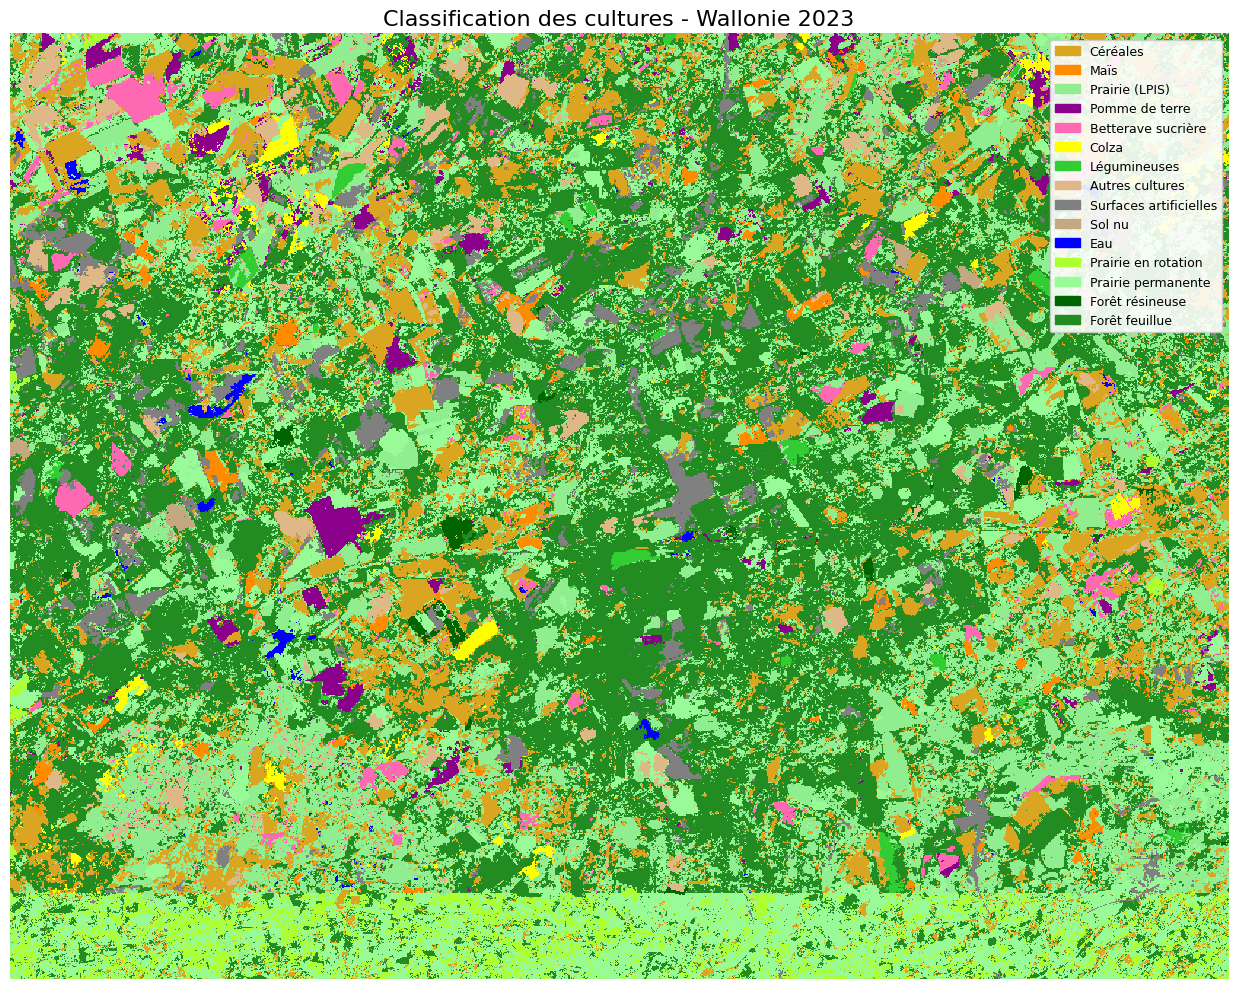

Saved final_crop_map_v2.png


In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

# Define classes, names, and colors
class_info = {
    100:  ('Céréales', '#DAA520'),
    200:  ('Maïs', '#FF8C00'),
    300:  ('Prairie (LPIS)', '#90EE90'),
    400:  ('Pomme de terre', '#8B008B'),
    500:  ('Betterave sucrière', '#FF69B4'),
    600:  ('Colza', '#FFFF00'),
    700:  ('Légumineuses', '#32CD32'),
    800:  ('Autres cultures', '#DEB887'),
    900:  ('Surfaces artificielles', '#808080'),
    1000: ('Sol nu', '#C4A882'),
    1100: ('Eau', '#0000FF'),
    1200: ('Prairie en rotation', '#ADFF2F'),
    1300: ('Prairie permanente', '#98FB98'),
    1400: ('Forêt résineuse', '#006400'),
    1500: ('Forêt feuillue', '#228B22'),
}


# 1. Get unique class codes from filtered_map
unique_classes = sorted([c for c in np.unique(filtered_map) if c in class_info])

# Build colormap
colors = [class_info[c][1] for c in unique_classes]
cmap = ListedColormap(colors)

# Map values to indices for plotting
plot_data = np.full_like(filtered_map, dtype=float, fill_value=np.nan)
for i, c in enumerate(unique_classes):
    plot_data[filtered_map == c] = i

# Build legend
patches = [mpatches.Patch(color=class_info[c][1], label=class_info[c][0]) for c in unique_classes]

# Plot
fig, ax = plt.subplots(figsize=(16, 10))
ax.imshow(plot_data, cmap=cmap, interpolation='nearest')
ax.legend(handles=patches, loc='upper right', fontsize=9, framealpha=0.9)
ax.set_title('Classification des cultures - Wallonie 2023', fontsize=16)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('final_crop_map_v2.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved final_crop_map_v2.png")

# ✅ Expected: colourful crop map with legend showing crop/landcover names

## Step 20 — Download Results

🎯 Download your final GeoTIFF results to the JupyterLab local filesystem so you can save them to your laptop.

Then right-click each file in the JupyterLab file browser and select **Download** to save to your local machine.

In [24]:
def download_blob(blob_name, local_path):
    data = get_cc().download_blob(blob_name).readall()
    with open(local_path, 'wb') as f:
        f.write(data)
    print(f"Downloaded: {local_path}")

download_blob('results/classification_RF.tif', 'classification_RF.tif')
download_blob('results/reclassification_RF_v2.tif', 'reclassification_RF_v2.tif')
download_blob('results/reclassification_RF_filtered.tif', 'reclassification_RF_filtered_v2.tif')

print("\nAll results downloaded.")

Downloaded: classification_RF.tif
Downloaded: reclassification_RF_v2.tif
Downloaded: reclassification_RF_filtered_v2.tif

All results downloaded.


## Step 21 — Clean Up Azure Resources

⚠️ **Do this only after downloading all results you want to keep.**

1. Go to **portal.azure.com**
2. **Resource groups** → your group resource group
3. Click **Delete resource group**
4. Type the resource group name to confirm → **Delete**

This removes all resources (compute instance, storage, ML workspace) and stops all costs permanently.

Your Azure for Students account and remaining $100 credit are **not affected**.

---

## 🎉 Congratulations!

You have built a complete end-to-end satellite image classification pipeline on Azure:

- ✅ Provisioned cloud infrastructure from scratch
- ✅ Downloaded Sentinel-2 multi-band data via the Copernicus S3 API
- ✅ Applied cloud masking and computed monthly composites
- ✅ Built a multi-temporal feature stack with spectral indices
- ✅ Selected informative features using Random Forest importance
- ✅ Trained and evaluated a crop type classifier
- ✅ Produced a final classified land cover map of Wallonia

---